# Grand Ensemble Experiment: K-Fold CV & Evaluation

1.  **Setup**: Load configuration.
2.  **Training**: Train 3 different model configurations using 5-Fold Cross-Validation (Total 15 models).
3.  **Evaluation**: Evaluate all 15 models on the held-out test set.

In [ ]:
import os
import sys
import torch
from src.utils import load_config
from src.train import train_k_fold
from src.ensemble import evaluate_grand_ensemble

# in the project root
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.append(project_root)

config = load_config()
print("Configuration Loaded.")
print(f"K-Folds: {config['hyperparameters']['k_folds']}")
print(f"Batch Size: {config['hyperparameters']['batch_size']}")
print(f"Epochs: {config['hyperparameters']['num_epochs']}")

Configuration Loaded.
K-Folds: 5
Batch Size: 8
Epochs: 15


## 1. Define Ensemble Components

Using `ensemble1`:
- ResNet101 (ImageNet)
- DenseNet161 (ImageNet)
- DenseNet161 (BACH)

In [2]:
# Select which ensemble configuration to use
ensemble_key = "ensemble1"
models_to_train = config[ensemble_key]["models"]

print(f"Selected Ensemble: {ensemble_key}")
for m in models_to_train:
    print(f" - {m['name']} (Norm: {m['normalisation']})")

Selected Ensemble: ensemble1
 - resnet101 (Norm: imagenet)
 - densenet161_1 (Norm: imagenet)
 - densenet161_2 (Norm: bach)


## 2. Run K-Fold Cross-Validation Training

This step iterates through each model configuration and runs 5-fold cross validation for each.

Total runs = 3 models * 5 folds = 15 training sessions.


==================== Training Model Config 1/3: resnet101 ====================

--- Initialising K-Fold Training Configuration ---
Using device: mps
Training Model: resnet101
Normalisation Scheme: imagenet
K-Folds: 5

--- Loading Dataset and Transforms ---
Total Dev Samples: 360, Hold-out Test Samples: 40

--- Starting Fold 1/5 ---
Fold 1 - Train samples: 288, Val samples: 72


/Users/niklaslongschiefelbein/local_documents/semester3/DLMIA/bach_challenge/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Epoch 1/15: 100%|██████████| 36/36 [00:46<00:00,  1.29s/it, acc=45.1, loss=1.26]


Epoch 1: Train Accuracy: 45.14%, Validation Accuracy: 72.22%
Saved best model to results/resnet101_bs8_lr0.0001/fold_0/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_0/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=72.9, loss=0.857]


Epoch 2: Train Accuracy: 72.92%, Validation Accuracy: 68.06%


...

Epoch 13: Train Accuracy: 94.79%, Validation Accuracy: 83.33%


Epoch 14/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=97.9, loss=0.0995]


Epoch 14: Train Accuracy: 97.92%, Validation Accuracy: 80.56%


Epoch 15/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=94.8, loss=0.121]


Epoch 15: Train Accuracy: 94.79%, Validation Accuracy: 84.72%
Saved best model to results/resnet101_bs8_lr0.0001/fold_0/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_0/best_model.pth


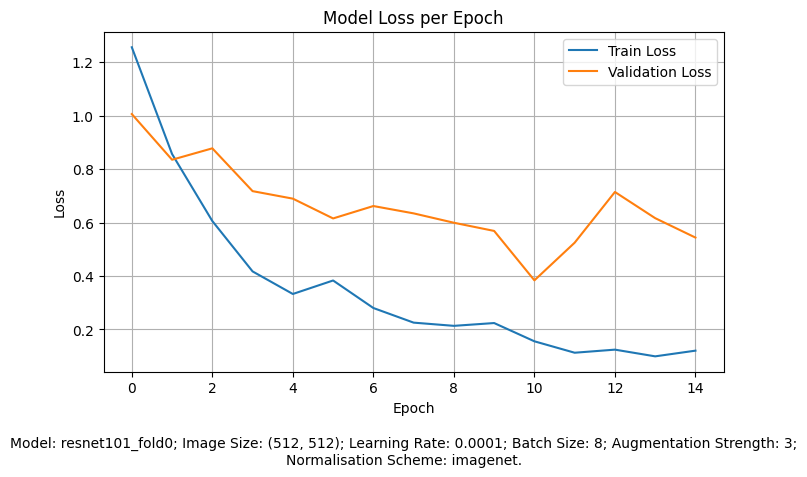

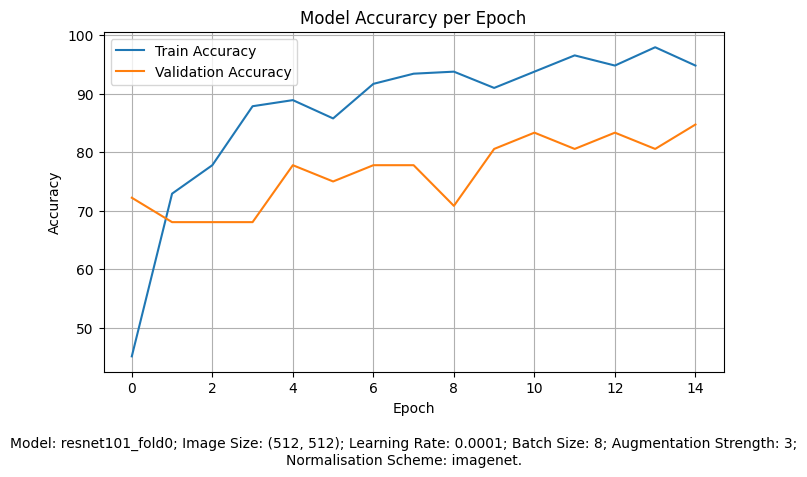


--- Starting Fold 2/5 ---
Fold 2 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=49.7, loss=1.25]


Epoch 1: Train Accuracy: 49.65%, Validation Accuracy: 62.50%
Saved best model to results/resnet101_bs8_lr0.0001/fold_1/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_1/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=67.7, loss=0.914]


Epoch 2: Train Accuracy: 67.71%, Validation Accuracy: 72.22%
Saved best model to results/resnet101_bs8_lr0.0001/fold_1/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_1/best_model.pth


...

Epoch 13: Train Accuracy: 94.44%, Validation Accuracy: 91.67%


Epoch 14/15: 100%|██████████| 36/36 [00:48<00:00,  1.35s/it, acc=95.8, loss=0.118]


Epoch 14: Train Accuracy: 95.83%, Validation Accuracy: 93.06%
Saved best model to results/resnet101_bs8_lr0.0001/fold_1/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_1/best_model.pth


Epoch 15/15: 100%|██████████| 36/36 [00:49<00:00,  1.37s/it, acc=95.1, loss=0.153]


Epoch 15: Train Accuracy: 95.14%, Validation Accuracy: 88.89%


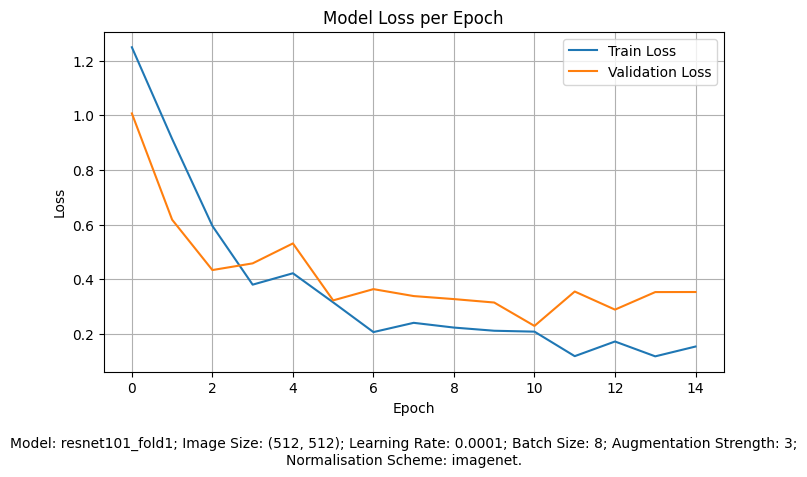

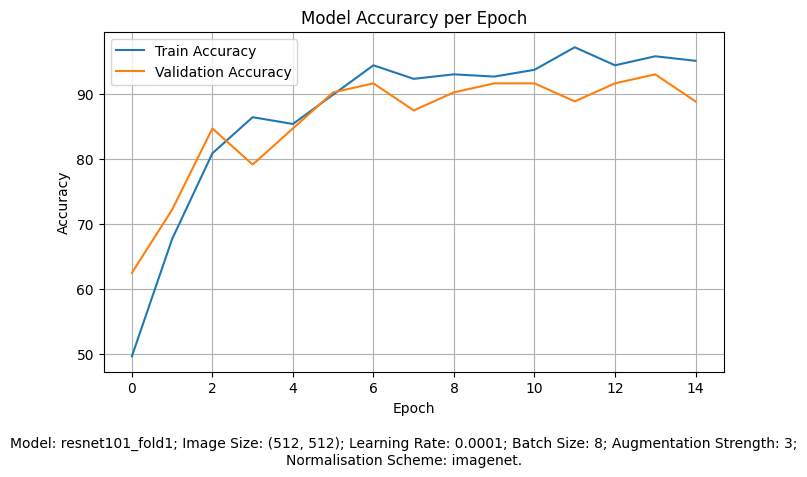


--- Starting Fold 3/5 ---
Fold 3 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [00:46<00:00,  1.29s/it, acc=47.9, loss=1.25]


Epoch 1: Train Accuracy: 47.92%, Validation Accuracy: 70.83%
Saved best model to results/resnet101_bs8_lr0.0001/fold_2/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_2/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=66, loss=0.907]


Epoch 2: Train Accuracy: 65.97%, Validation Accuracy: 77.78%
Saved best model to results/resnet101_bs8_lr0.0001/fold_2/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_2/best_model.pth


...

Epoch 13: Train Accuracy: 93.06%, Validation Accuracy: 88.89%


Epoch 14/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=95.5, loss=0.152]


Epoch 14: Train Accuracy: 95.49%, Validation Accuracy: 91.67%


Epoch 15/15: 100%|██████████| 36/36 [00:46<00:00,  1.30s/it, acc=93.4, loss=0.188]


Epoch 15: Train Accuracy: 93.40%, Validation Accuracy: 88.89%


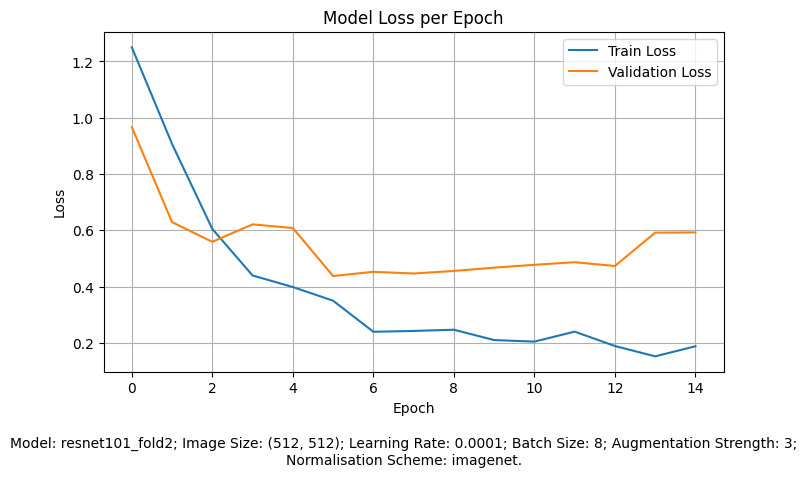

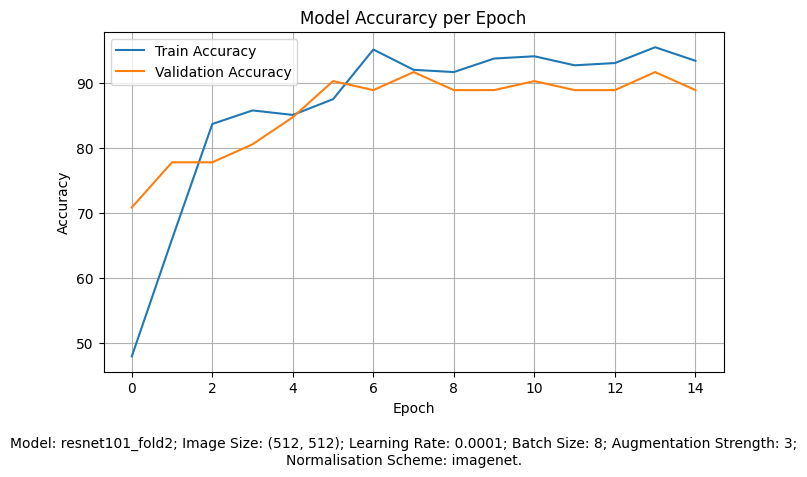


--- Starting Fold 4/5 ---
Fold 4 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [00:46<00:00,  1.29s/it, acc=37.5, loss=1.29]


Epoch 1: Train Accuracy: 37.50%, Validation Accuracy: 68.06%
Saved best model to results/resnet101_bs8_lr0.0001/fold_3/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_3/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=69.4, loss=0.92]


Epoch 2: Train Accuracy: 69.44%, Validation Accuracy: 76.39%
Saved best model to results/resnet101_bs8_lr0.0001/fold_3/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_3/best_model.pth


...

Epoch 13: Train Accuracy: 96.53%, Validation Accuracy: 86.11%


Epoch 14/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=95.5, loss=0.122]


Epoch 14: Train Accuracy: 95.49%, Validation Accuracy: 77.78%


Epoch 15/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=96.9, loss=0.13]


Epoch 15: Train Accuracy: 96.88%, Validation Accuracy: 87.50%


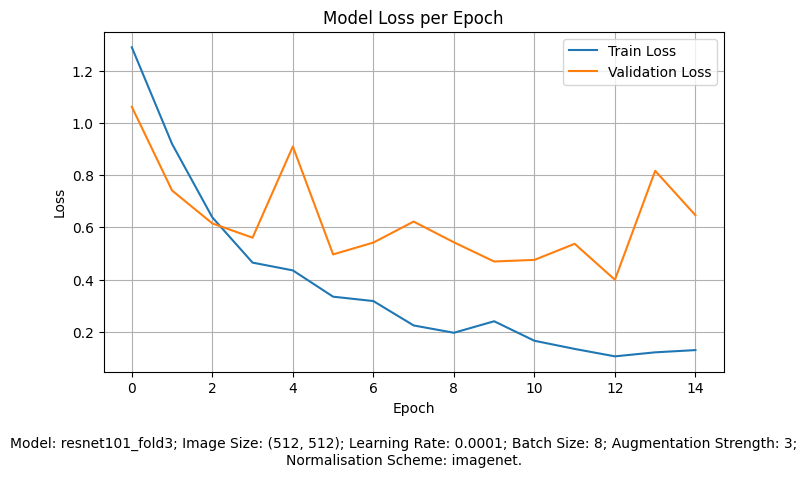

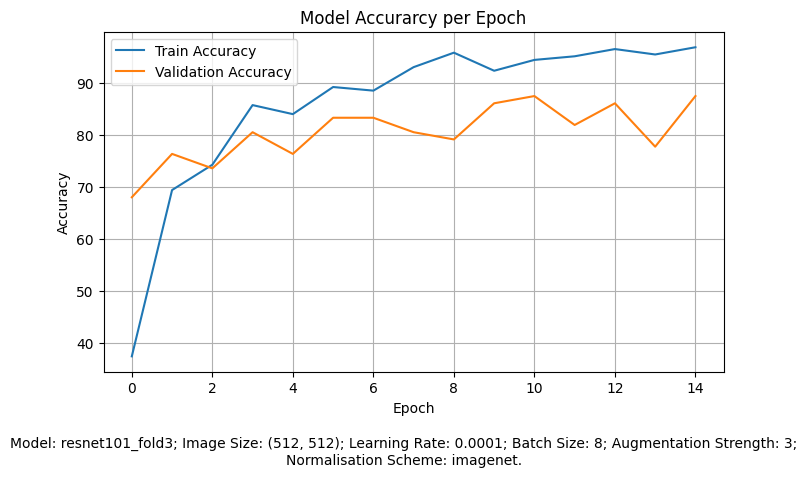


--- Starting Fold 5/5 ---
Fold 5 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [00:46<00:00,  1.29s/it, acc=50.3, loss=1.24]


Epoch 1: Train Accuracy: 50.35%, Validation Accuracy: 63.89%
Saved best model to results/resnet101_bs8_lr0.0001/fold_4/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_4/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=70.1, loss=0.851]


Epoch 2: Train Accuracy: 70.14%, Validation Accuracy: 81.94%
Saved best model to results/resnet101_bs8_lr0.0001/fold_4/best_model.pth
Saved best model to results/resnet101_bs8_lr0.0001/fold_4/best_model.pth


...

Epoch 13: Train Accuracy: 96.88%, Validation Accuracy: 88.89%


Epoch 14/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=99, loss=0.0624]


Epoch 14: Train Accuracy: 98.96%, Validation Accuracy: 83.33%


Epoch 15/15: 100%|██████████| 36/36 [00:46<00:00,  1.28s/it, acc=96.5, loss=0.0904]


Epoch 15: Train Accuracy: 96.53%, Validation Accuracy: 87.50%


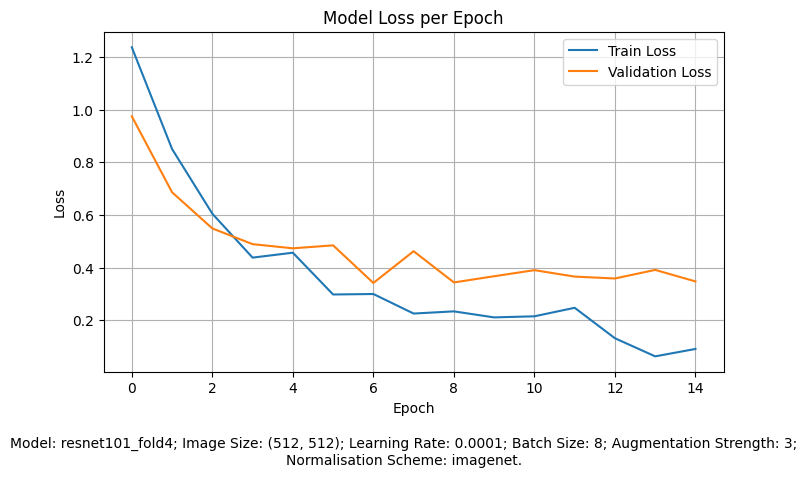

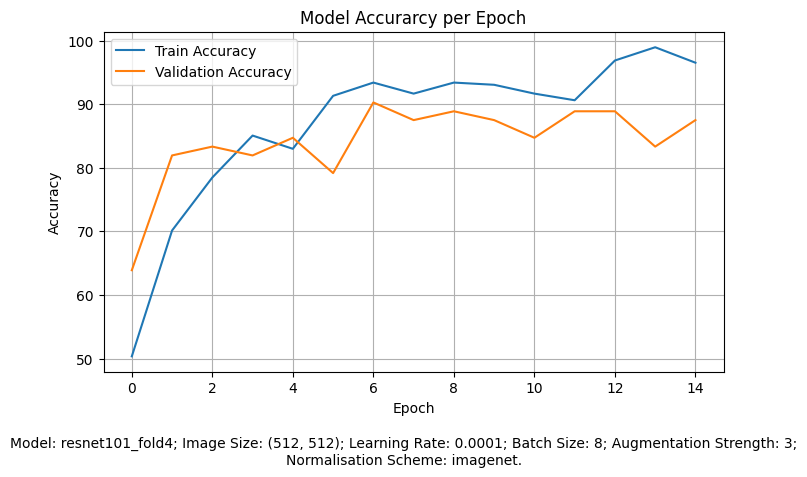


==================== Training Model Config 2/3: densenet161_1 ====================

--- Initialising K-Fold Training Configuration ---
Using device: mps
Training Model: densenet161_1
Normalisation Scheme: imagenet
K-Folds: 5

--- Loading Dataset and Transforms ---
Total Dev Samples: 360, Hold-out Test Samples: 40

--- Starting Fold 1/5 ---
Fold 1 - Train samples: 288, Val samples: 72


/Users/niklaslongschiefelbein/local_documents/semester3/DLMIA/bach_challenge/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Epoch 1/15: 100%|██████████| 36/36 [01:02<00:00,  1.74s/it, acc=56.2, loss=1.04]


Epoch 1: Train Accuracy: 56.25%, Validation Accuracy: 69.44%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_0/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_0/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:01<00:00,  1.70s/it, acc=82.3, loss=0.559]


Epoch 2: Train Accuracy: 82.29%, Validation Accuracy: 70.83%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_0/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_0/best_model.pth


...

Epoch 13: Train Accuracy: 97.22%, Validation Accuracy: 84.72%


Epoch 14/15: 100%|██████████| 36/36 [01:01<00:00,  1.71s/it, acc=96.9, loss=0.108]


Epoch 14: Train Accuracy: 96.88%, Validation Accuracy: 80.56%


Epoch 15/15: 100%|██████████| 36/36 [01:01<00:00,  1.71s/it, acc=99, loss=0.0648]


Epoch 15: Train Accuracy: 98.96%, Validation Accuracy: 84.72%


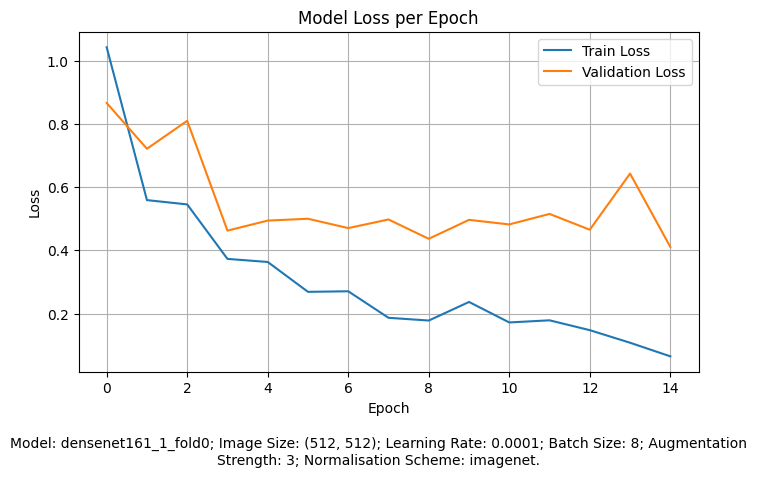

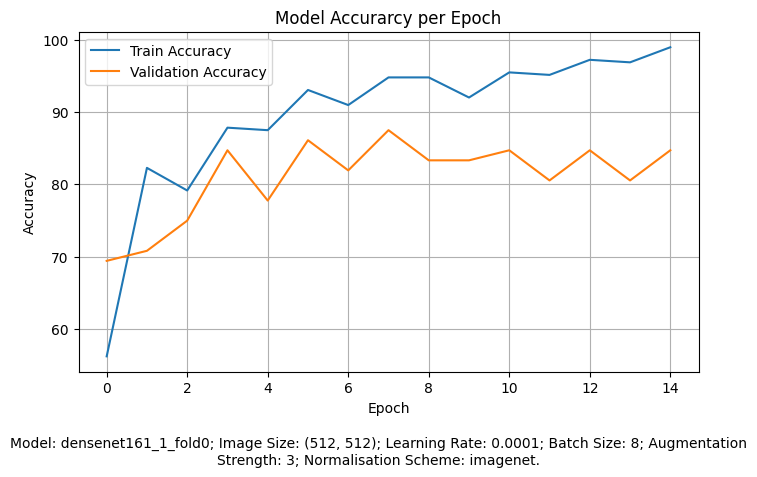


--- Starting Fold 2/5 ---
Fold 2 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=57.6, loss=1.02]


Epoch 1: Train Accuracy: 57.64%, Validation Accuracy: 72.22%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_1/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_1/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:01<00:00,  1.72s/it, acc=80.2, loss=0.602]


Epoch 2: Train Accuracy: 80.21%, Validation Accuracy: 80.56%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_1/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_1/best_model.pth


...

Epoch 13: Train Accuracy: 93.06%, Validation Accuracy: 84.72%


Epoch 14/15: 100%|██████████| 36/36 [01:01<00:00,  1.72s/it, acc=93.8, loss=0.2]


Epoch 14: Train Accuracy: 93.75%, Validation Accuracy: 94.44%


Epoch 15/15: 100%|██████████| 36/36 [01:01<00:00,  1.72s/it, acc=96.9, loss=0.153]


Epoch 15: Train Accuracy: 96.88%, Validation Accuracy: 94.44%


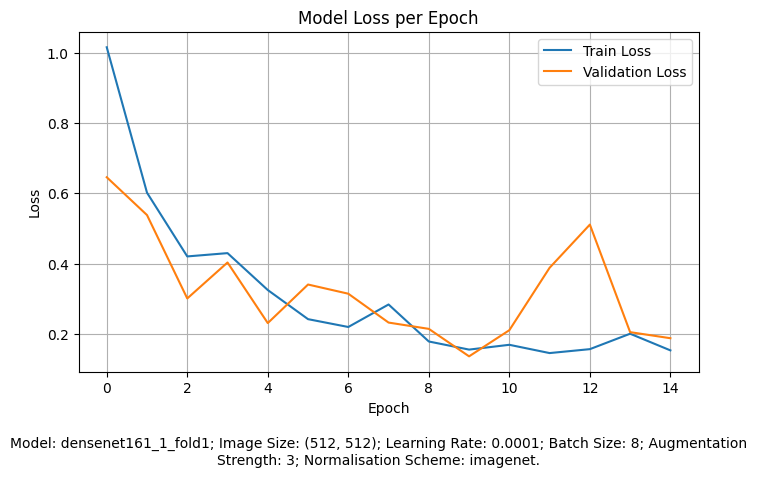

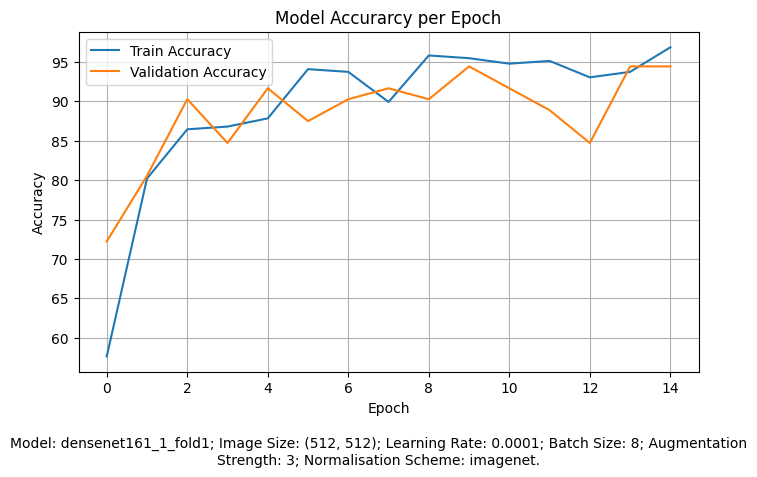


--- Starting Fold 3/5 ---
Fold 3 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:02<00:00,  1.72s/it, acc=59, loss=1.02]


Epoch 1: Train Accuracy: 59.03%, Validation Accuracy: 76.39%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_2/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_2/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:01<00:00,  1.72s/it, acc=73.3, loss=0.697]


Epoch 2: Train Accuracy: 73.26%, Validation Accuracy: 76.39%


...

Epoch 13: Train Accuracy: 95.49%, Validation Accuracy: 87.50%


Epoch 14/15: 100%|██████████| 36/36 [01:01<00:00,  1.71s/it, acc=95.8, loss=0.148]


Epoch 14: Train Accuracy: 95.83%, Validation Accuracy: 86.11%


Epoch 15/15: 100%|██████████| 36/36 [01:01<00:00,  1.71s/it, acc=96.5, loss=0.119]


Epoch 15: Train Accuracy: 96.53%, Validation Accuracy: 90.28%


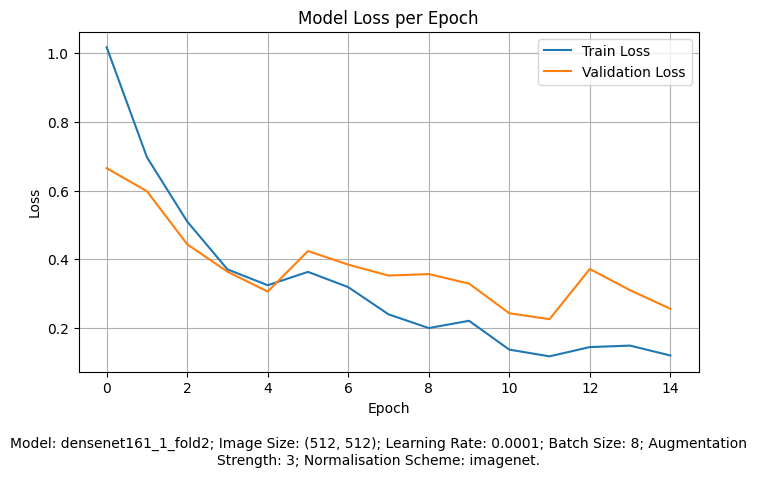

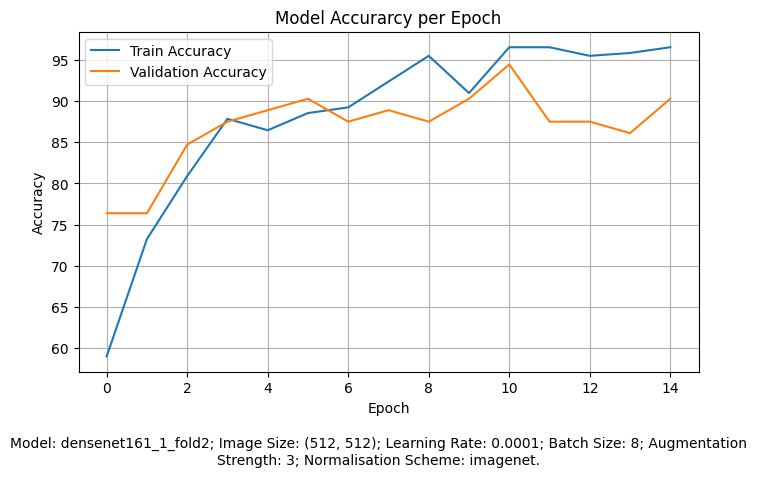


--- Starting Fold 4/5 ---
Fold 4 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:02<00:00,  1.74s/it, acc=58.3, loss=1.01]


Epoch 1: Train Accuracy: 58.33%, Validation Accuracy: 79.17%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_3/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_3/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:01<00:00,  1.71s/it, acc=78.5, loss=0.611]


Epoch 2: Train Accuracy: 78.47%, Validation Accuracy: 91.67%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_3/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_3/best_model.pth


...

Epoch 13: Train Accuracy: 95.14%, Validation Accuracy: 83.33%


Epoch 14/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=94.1, loss=0.165]


Epoch 14: Train Accuracy: 94.10%, Validation Accuracy: 83.33%


Epoch 15/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=93.4, loss=0.167]


Epoch 15: Train Accuracy: 93.40%, Validation Accuracy: 87.50%


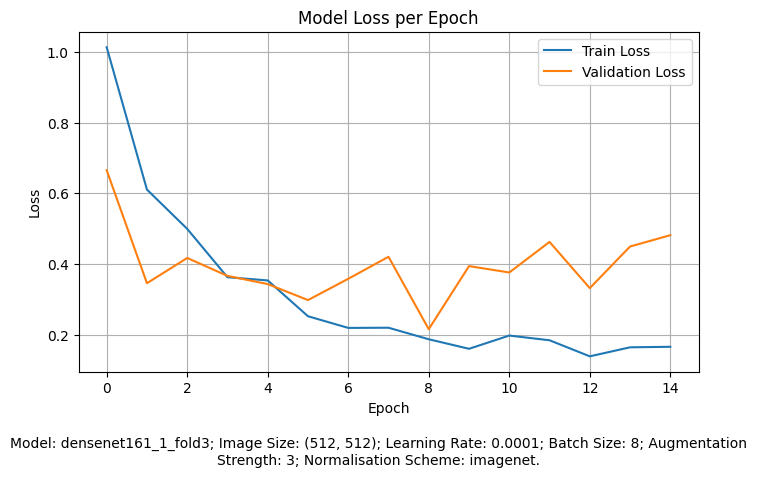

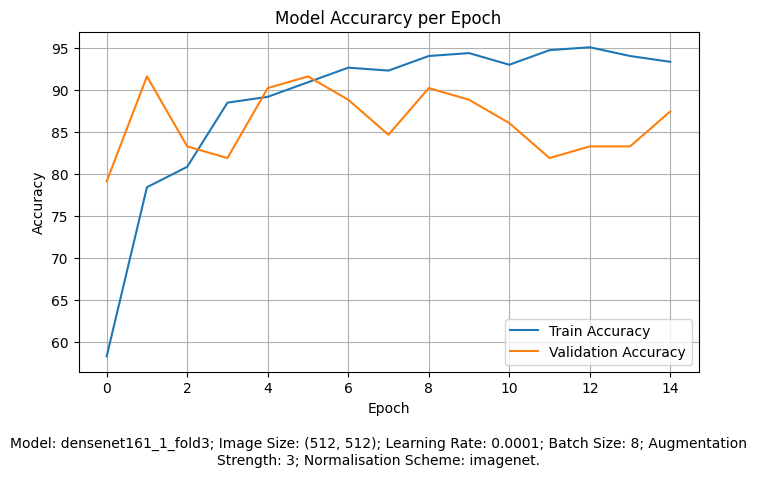


--- Starting Fold 5/5 ---
Fold 5 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=56.6, loss=1.01] 



Epoch 1: Train Accuracy: 56.60%, Validation Accuracy: 77.78%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_4/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_4/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:02<00:00,  1.75s/it, acc=75.3, loss=0.622]


Epoch 2: Train Accuracy: 75.35%, Validation Accuracy: 79.17%
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_4/best_model.pth
Saved best model to results/densenet161_1_bs8_lr0.0001/fold_4/best_model.pth


...

Epoch 13: Train Accuracy: 97.57%, Validation Accuracy: 94.44%


Epoch 14/15: 100%|██████████| 36/36 [01:03<00:00,  1.77s/it, acc=97.9, loss=0.0993]


Epoch 14: Train Accuracy: 97.92%, Validation Accuracy: 94.44%


Epoch 15/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=96.2, loss=0.154]


Epoch 15: Train Accuracy: 96.18%, Validation Accuracy: 93.06%


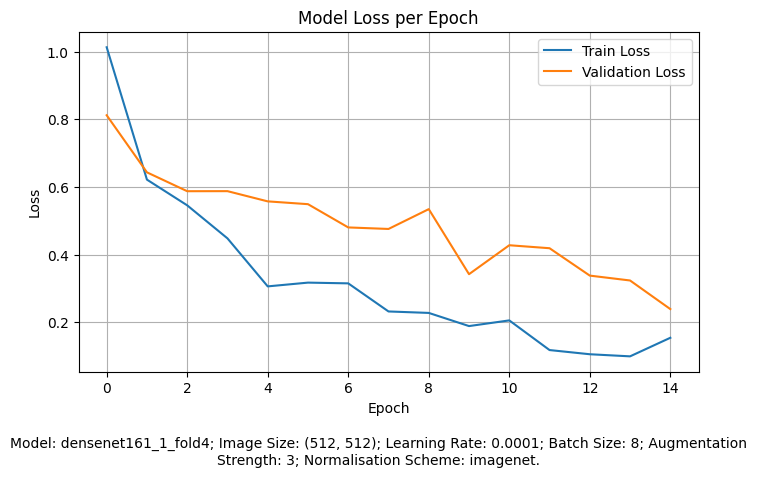

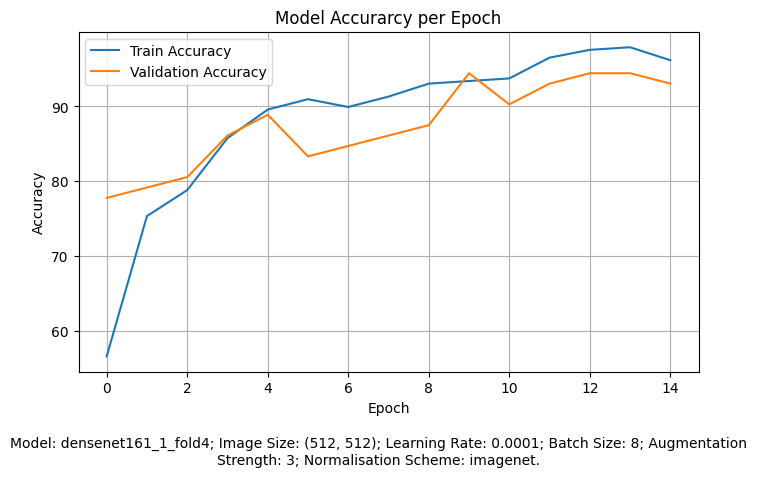


==================== Training Model Config 3/3: densenet161_2 ====================

--- Initialising K-Fold Training Configuration ---
Using device: mps
Training Model: densenet161_2
Normalisation Scheme: bach
K-Folds: 5

--- Loading Dataset and Transforms ---
Total Dev Samples: 360, Hold-out Test Samples: 40

--- Starting Fold 1/5 ---
Fold 1 - Train samples: 288, Val samples: 72
Total Dev Samples: 360, Hold-out Test Samples: 40

--- Starting Fold 1/5 ---
Fold 1 - Train samples: 288, Val samples: 72


/Users/niklaslongschiefelbein/local_documents/semester3/DLMIA/bach_challenge/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Epoch 1/15: 100%|██████████| 36/36 [01:02<00:00,  1.74s/it, acc=57.3, loss=1.04]


Epoch 1: Train Accuracy: 57.29%, Validation Accuracy: 73.61%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_0/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_0/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:02<00:00,  1.74s/it, acc=79.2, loss=0.581]


Epoch 2: Train Accuracy: 79.17%, Validation Accuracy: 77.78%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_0/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_0/best_model.pth


...

Epoch 13: Train Accuracy: 96.53%, Validation Accuracy: 81.94%


Epoch 14/15: 100%|██████████| 36/36 [01:03<00:00,  1.76s/it, acc=94.4, loss=0.16]


Epoch 14: Train Accuracy: 94.44%, Validation Accuracy: 83.33%


Epoch 15/15: 100%|██████████| 36/36 [01:01<00:00,  1.72s/it, acc=93.4, loss=0.166]


Epoch 15: Train Accuracy: 93.40%, Validation Accuracy: 80.56%


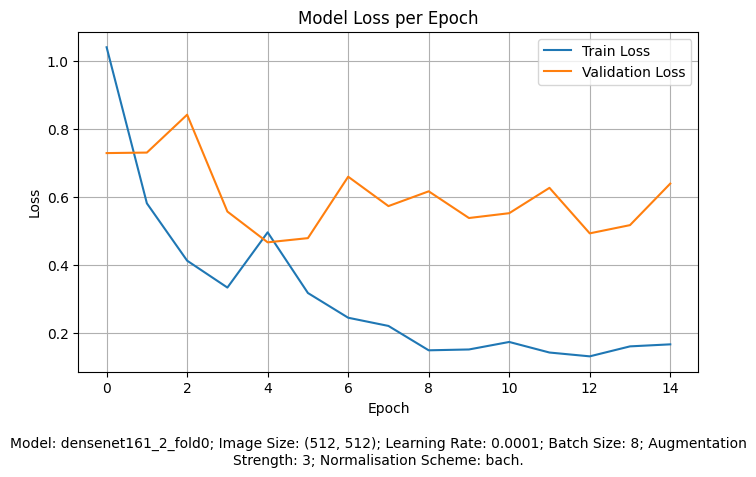

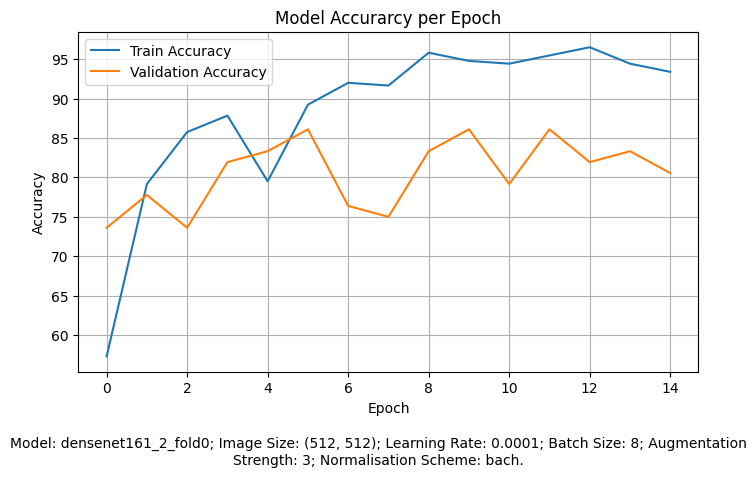


--- Starting Fold 2/5 ---
Fold 2 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:03<00:00,  1.77s/it, acc=54.5, loss=1.04]


Epoch 1: Train Accuracy: 54.51%, Validation Accuracy: 77.78%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_1/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_1/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=78.8, loss=0.615]


Epoch 2: Train Accuracy: 78.82%, Validation Accuracy: 84.72%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_1/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_1/best_model.pth


...

Epoch 13: Train Accuracy: 96.18%, Validation Accuracy: 91.67%


Epoch 14/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=96.2, loss=0.149]


Epoch 14: Train Accuracy: 96.18%, Validation Accuracy: 87.50%


Epoch 15/15: 100%|██████████| 36/36 [01:02<00:00,  1.74s/it, acc=96.5, loss=0.0896]


Epoch 15: Train Accuracy: 96.53%, Validation Accuracy: 88.89%


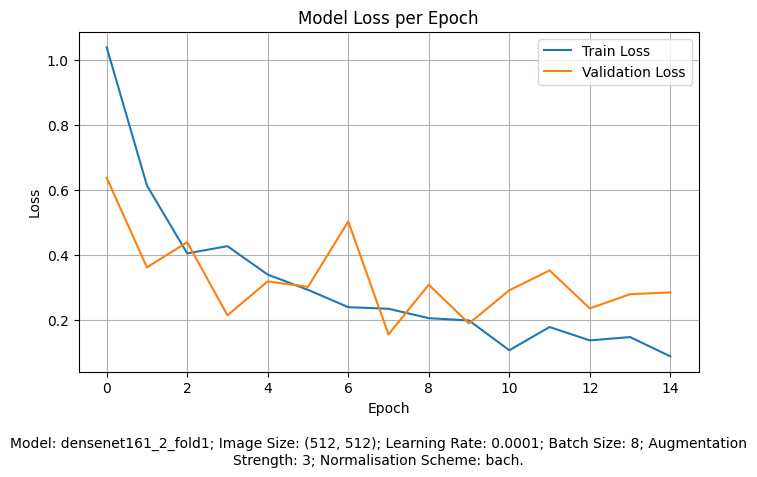

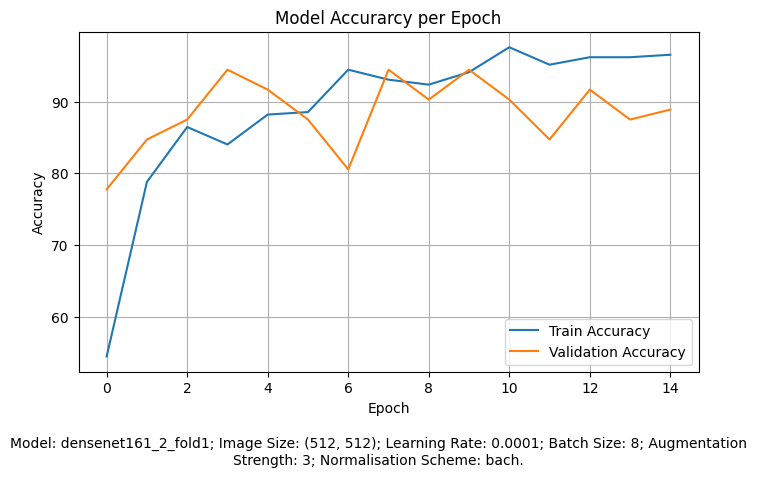


--- Starting Fold 3/5 ---
Fold 3 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:02<00:00,  1.73s/it, acc=54.5, loss=1.06] 



Epoch 1: Train Accuracy: 54.51%, Validation Accuracy: 68.06%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_2/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_2/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:02<00:00,  1.74s/it, acc=72.6, loss=0.689]


Epoch 2: Train Accuracy: 72.57%, Validation Accuracy: 77.78%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_2/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_2/best_model.pth


...

Epoch 13: Train Accuracy: 98.61%, Validation Accuracy: 90.28%


Epoch 14/15: 100%|██████████| 36/36 [01:05<00:00,  1.82s/it, acc=96.2, loss=0.138]


Epoch 14: Train Accuracy: 96.18%, Validation Accuracy: 90.28%


Epoch 15/15: 100%|██████████| 36/36 [01:04<00:00,  1.79s/it, acc=94.8, loss=0.156]


Epoch 15: Train Accuracy: 94.79%, Validation Accuracy: 90.28%


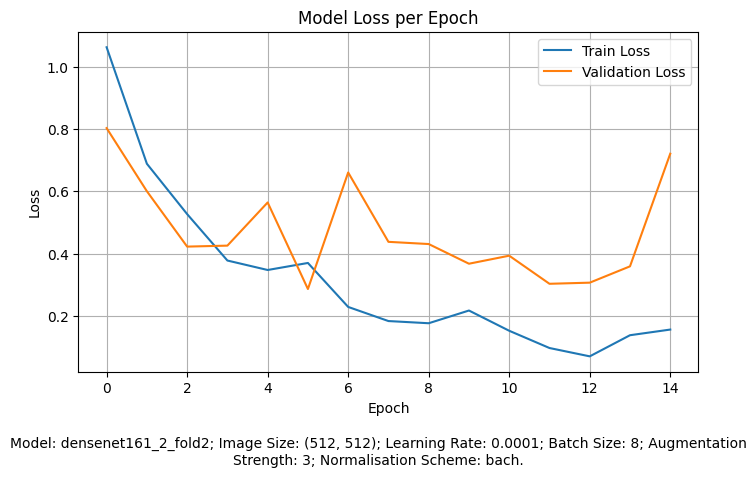

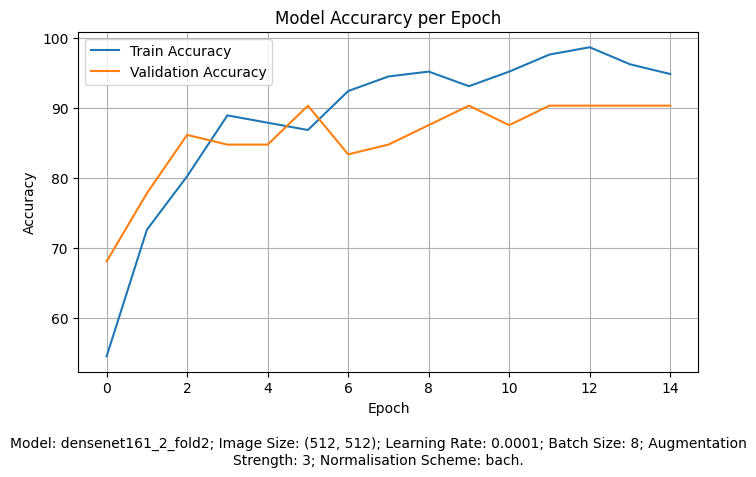


--- Starting Fold 4/5 ---
Fold 4 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:05<00:00,  1.83s/it, acc=54.5, loss=1.03]


Epoch 1: Train Accuracy: 54.51%, Validation Accuracy: 75.00%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_3/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_3/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:04<00:00,  1.80s/it, acc=75.7, loss=0.689]


Epoch 2: Train Accuracy: 75.69%, Validation Accuracy: 73.61%


...

Epoch 13: Train Accuracy: 92.01%, Validation Accuracy: 87.50%


Epoch 14/15: 100%|██████████| 36/36 [01:04<00:00,  1.78s/it, acc=96.9, loss=0.117]


Epoch 14: Train Accuracy: 96.88%, Validation Accuracy: 90.28%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_3/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_3/best_model.pth


Epoch 15/15: 100%|██████████| 36/36 [01:04<00:00,  1.80s/it, acc=94.8, loss=0.187]


Epoch 15: Train Accuracy: 94.79%, Validation Accuracy: 90.28%


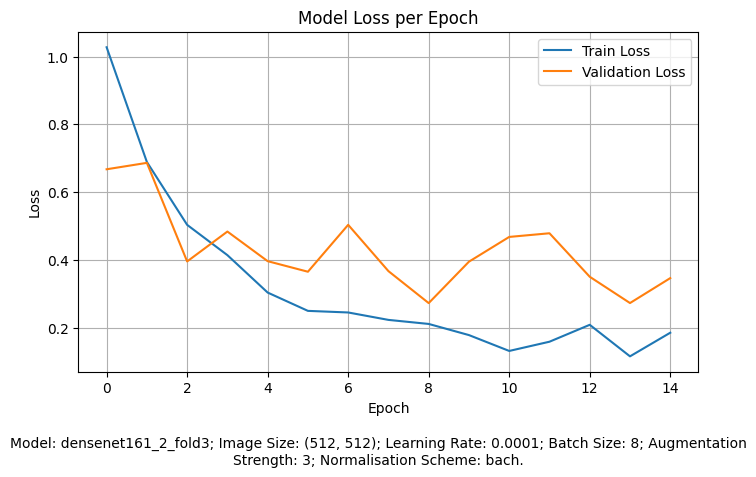

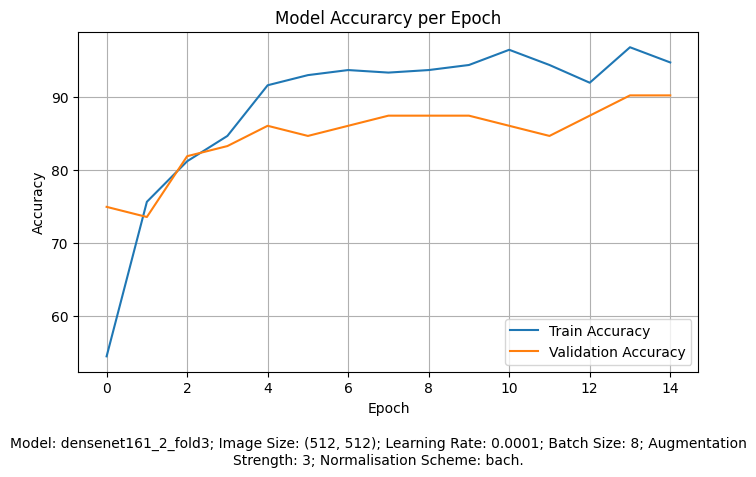


--- Starting Fold 5/5 ---
Fold 5 - Train samples: 288, Val samples: 72


Epoch 1/15: 100%|██████████| 36/36 [01:05<00:00,  1.82s/it, acc=55.6, loss=0.997]


Epoch 1: Train Accuracy: 55.56%, Validation Accuracy: 70.83%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_4/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_4/best_model.pth


Epoch 2/15: 100%|██████████| 36/36 [01:04<00:00,  1.80s/it, acc=74.7, loss=0.643]


Epoch 2: Train Accuracy: 74.65%, Validation Accuracy: 86.11%
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_4/best_model.pth
Saved best model to results/densenet161_2_bs8_lr0.0001/fold_4/best_model.pth


...

Epoch 13: Train Accuracy: 93.40%, Validation Accuracy: 87.50%


Epoch 14/15: 100%|██████████| 36/36 [01:04<00:00,  1.80s/it, acc=96.2, loss=0.163]


Epoch 14: Train Accuracy: 96.18%, Validation Accuracy: 86.11%


Epoch 15/15: 100%|██████████| 36/36 [01:04<00:00,  1.79s/it, acc=97.6, loss=0.114]


Epoch 15: Train Accuracy: 97.57%, Validation Accuracy: 83.33%


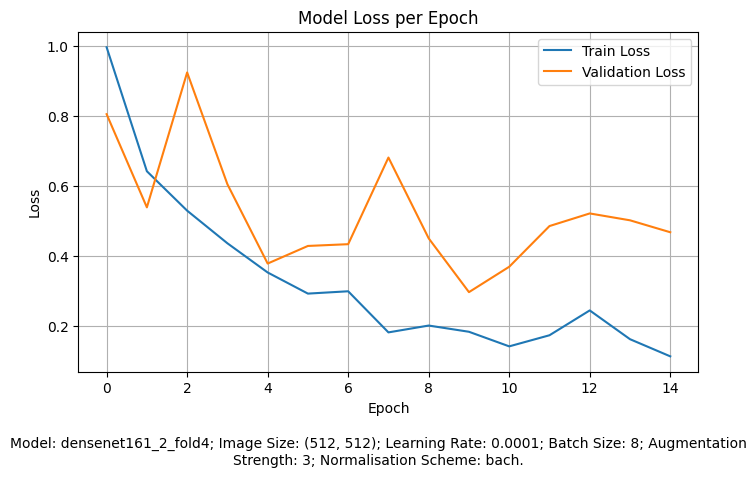

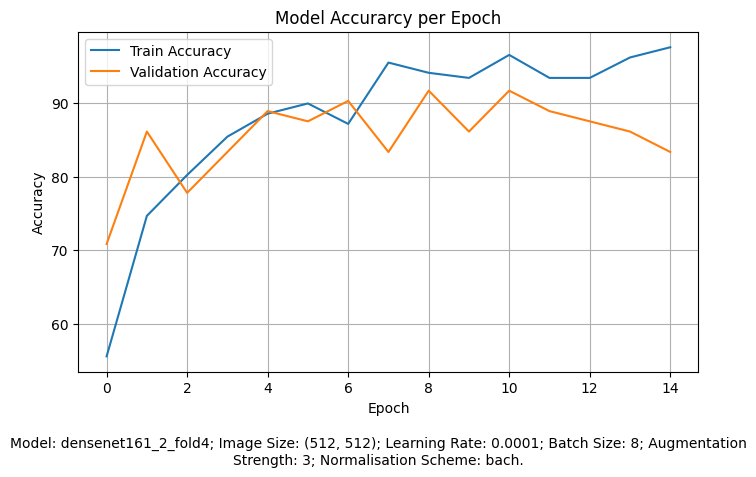


All training sessions completed.


In [3]:
for i, model_config in enumerate(models_to_train):
    print(
        f"\n{'='*20} Training Model Config {i+1}/{len(models_to_train)}: {model_config['name']} {'='*20}"
    )

    train_k_fold(
        model_name=model_config["name"],
        learning_rate=0.0001,
        augmentation_strength=3,
        normalisation_scheme=model_config["normalisation"],
    )

print("\nAll training sessions completed.")

## 3. Evaluate Grand Ensemble

After training all 15 models, load them all and perform soft voting on the hold-out test set.


--- Preparing Grand Ensemble Evaluation ---
Evaluating on 40 Hold-out Test samples.
Loading resnet101 (Fold 0) with imagenet norm...
Loading resnet101 (Fold 0) with imagenet norm...
Loading resnet101 (Fold 1) with imagenet norm...
Loading resnet101 (Fold 1) with imagenet norm...
Loading resnet101 (Fold 2) with imagenet norm...
Loading resnet101 (Fold 2) with imagenet norm...
Loading resnet101 (Fold 3) with imagenet norm...
Loading resnet101 (Fold 3) with imagenet norm...
Loading resnet101 (Fold 4) with imagenet norm...
Loading resnet101 (Fold 4) with imagenet norm...
Loading densenet161_1 (Fold 0) with imagenet norm...
Loading densenet161_1 (Fold 0) with imagenet norm...
Loading densenet161_1 (Fold 1) with imagenet norm...
Loading densenet161_1 (Fold 1) with imagenet norm...
Loading densenet161_1 (Fold 2) with imagenet norm...
Loading densenet161_1 (Fold 2) with imagenet norm...
Loading densenet161_1 (Fold 3) with imagenet norm...
Loading densenet161_1 (Fold 3) with imagenet norm...
L

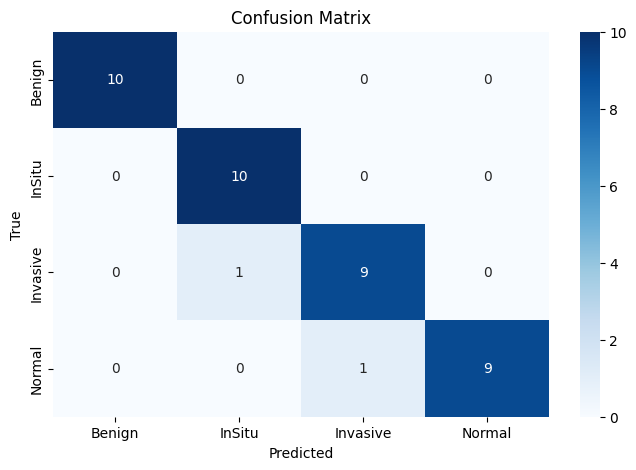

In [3]:
evaluate_grand_ensemble(
    model_configs=models_to_train,
    k_folds=config['hyperparameters']['k_folds']
)